In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wavfile
from statsmodels.tsa.stattools import acf
import pyreaper
from scipy.signal import find_peaks
import math

In [2]:
def plot_signal(signal: np.ndarray, fs: int = 44100, duration: float = 5):
    """ Визуализация сигнала """
    plt.figure(figsize=(10, 4))
    time_counts = np.linspace(0, duration, int(fs * duration))
    plt.plot(time_counts, signal[:len(time_counts)])
    plt.xlabel("Время (с)")
    plt.ylabel("Амплитуда")
    plt.title("Входной звуковой сигнал")
    plt.grid()
    plt.show()

In [3]:
def plot_characteristics(x: np.ndarray, title: str, x_label: str, y_label: str):
    """ Визуализация графиков """
    plt.figure(figsize=(10, 4))
    plt.plot(range(len(x)), x)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid()
    plt.show()

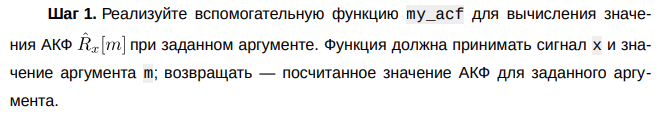

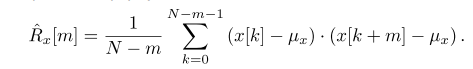

In [4]:
def my_acf(x: np.ndarray, m: int):
    N = len(x)
    u_x = np.mean(x)
    R_x = 0
    for i in range(N-m):
        R_x += (x[i] - u_x) * (x[i + m] - u_x)
    return R_x / (N - m)

In [ ]:
fs, x = wavfile.read('input.wav')
if x.ndim == 2:
    x = x[:,0]
    
x = x[fs:]  # Удаление 1 секунды молчания
x = x.astype(np.float32) / max(abs(x.min()), abs(x.max()))

plot_signal(x, fs)

FileNotFoundError: [Errno 2] No such file or directory: 'sound.wav'

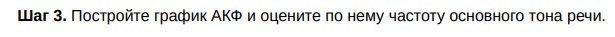

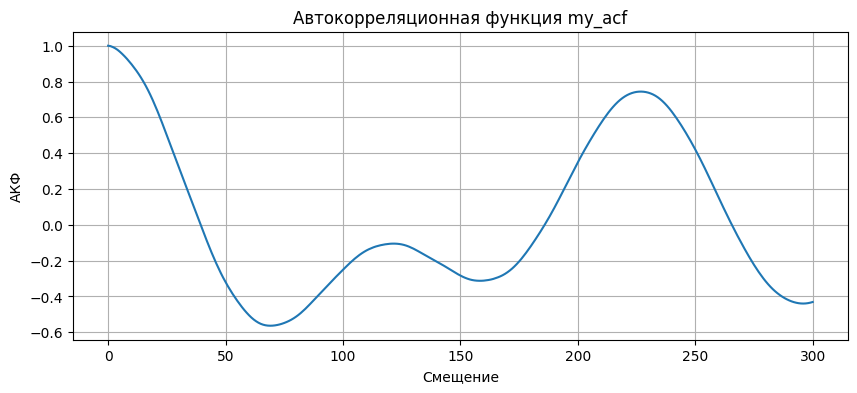

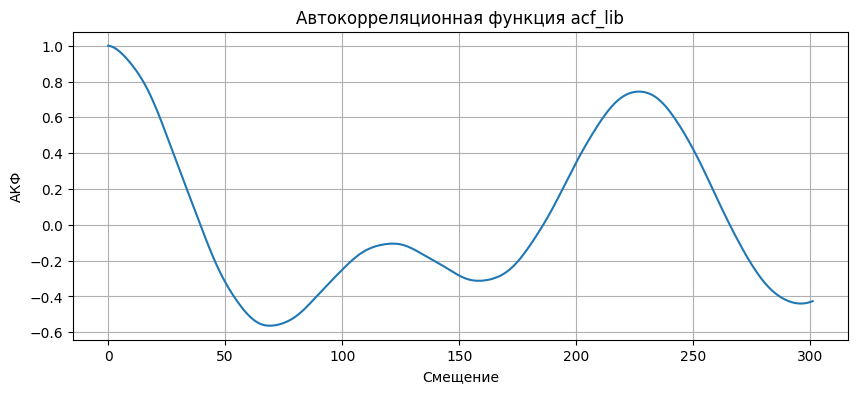

In [ ]:
AKF = []
M = 301
for m in range(M):
    AKF.append(my_acf(x[:fs], m))
AKF = np.array(AKF)
AKF /= max(AKF)
plot_characteristics(AKF, "Автокорреляционная функция my_acf", "Смещение", "АКФ")

acf_lib = acf(x[:fs], nlags=M, adjusted=True)
plot_characteristics(acf_lib, "Автокорреляционная функция acf_lib", "Смещение", "АКФ")

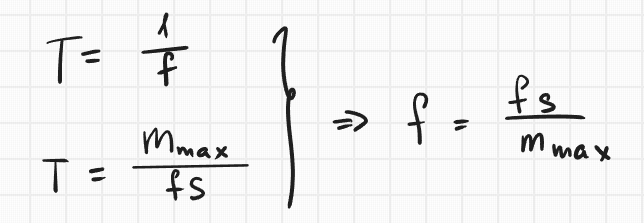

In [ ]:
peaks, _ = find_peaks(AKF, height=0.2)  
if len(peaks) > 0:
    m_peak = peaks[0]  
    F0 = fs / m_peak  
    print(f"Частота основного тона речи: {F0:.2f} Гц")
else:
    print("Не удалось определить основную частоту речи.")


Частота основного тона речи: 211.45 Гц


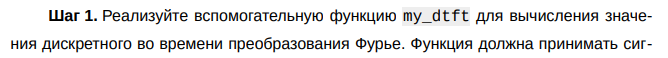

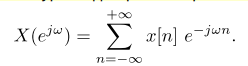

In [ ]:
def my_dtft(x: np.ndarray, fs: int, freqs: np.ndarray):
    """ ДВПФ """
    N = len(x)  
    n = np.arange(N) 
    spectrum = []  
    for f in freqs:
        w = 2 * np.pi * f / fs
        S_f = np.dot(x, np.exp(-1j * n * w)) 
        spectrum.append(np.abs(S_f))  

    return np.array(spectrum)  

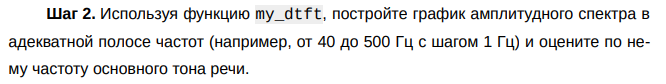

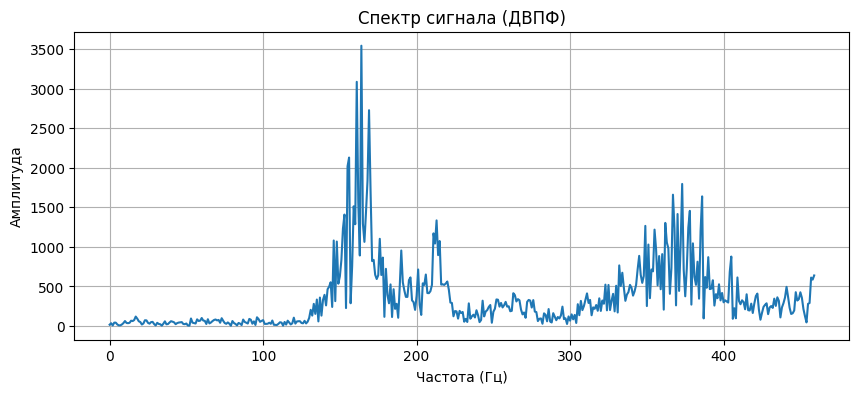

Оценка основной частоты (ДВПФ): 204.00 Гц


In [ ]:
freqs = np.arange(40, 500, 1)
spectrum = my_dtft(x, fs, freqs)
plot_characteristics(spectrum, "Спектр сигнала (ДВПФ)", "Частота (Гц)", "Амплитуда")
f_dtft = freqs[np.argmax(spectrum)]
print(f"Оценка основной частоты (ДВПФ): {f_dtft:.2f} Гц")

In [ ]:
def estimate_fundamental_frequency(x, fs):
    """ Оценка основной частоты речи с использованием PyReaper """

    t = np.linspace(0, (len(x) - 1) / fs, len(x))

    int16_info = np.iinfo(np.int16)
    x = x * min(int16_info.min, int16_info.max) 
    x = x.astype(np.int16)

   
    pm_times, pm, f_times, f, _ = pyreaper.reaper(x, fs)


    plt.figure('[Reaper] Pitch Marks')
    plt.plot(t, x, label="Сигнал")
    plt.scatter(pm_times[pm == 1], x[(pm_times * fs).astype(int)][pm == 1], 
                marker='x', color='red', label="Pitch Marks")
    plt.legend()
    plt.xlabel("Время (с)")
    plt.ylabel("Амплитуда")

    plt.figure('[Reaper] Fundamental Frequency')
    plt.plot(f_times, f, label="Основная частота")
    plt.xlabel("Время (с)")
    plt.ylabel("Частота (Гц)")
    plt.legend()
    plt.show()

    f0_avg = np.mean(f[f != -1])       

    return f0_avg

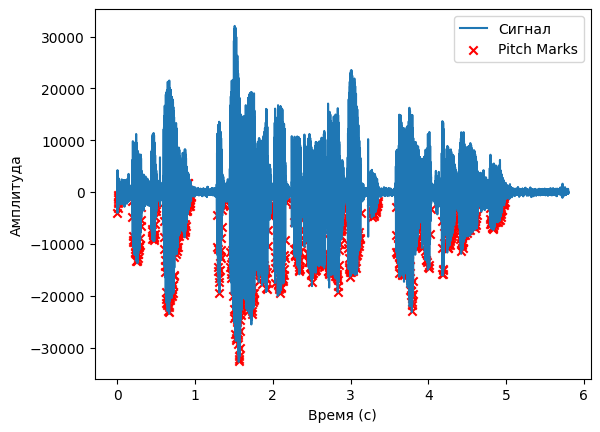

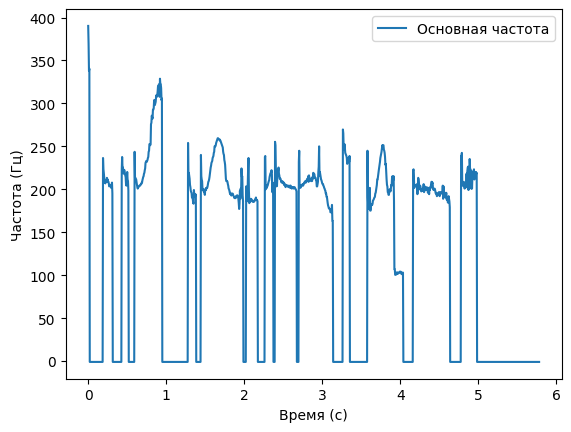

Средняя основная частота: 210.77 Гц


In [ ]:
print(f'Средняя основная частота: {estimate_fundamental_frequency(x, fs):.2f} Гц')

In [ ]:
def window_function(x, b, c):
    x_arr = np.linspace(0, x, x)
    y_arr = np.zeros(len(x_arr))
    
    for i in range(0, len(x_arr)):
        y_arr[i] = math.exp(- ((x_arr[i] - b)**2 ) / 2 / (c**2))
    
    return  y_arr

In [ ]:
def my_psola(x, fs, k):
    int16_info = np.iinfo(np.int16)
    x = x * min(int16_info.min, int16_info.max) 
    x = x.astype(np.int16)
    pm_times, pm, _, _, _ = pyreaper.reaper(x, fs)
    peaks = pm_times[pm == 1] 
    
    T = np.diff(peaks) * fs 
    res_length = int(k * len(x))
    res = np.zeros(res_length, dtype=np.float32)

    shift = 0 

    for i in range(len(T)):
        t1 = int(peaks[i] * fs) - int(k * T[i]) 
        t2 = int(peaks[i] * fs) + int(k * T[i]) 
                
        if t1 < 0 or t2 >= len(x):
            continue

        sector = x[t1:t2]  

        window = window_function(len(sector), len(sector) / 2, (t2 - t1) / 6)        
        res[shift:shift + len(sector)] += sector * window

        shift += int(k * T[i])      
    return res / np.max(np.abs(res))  

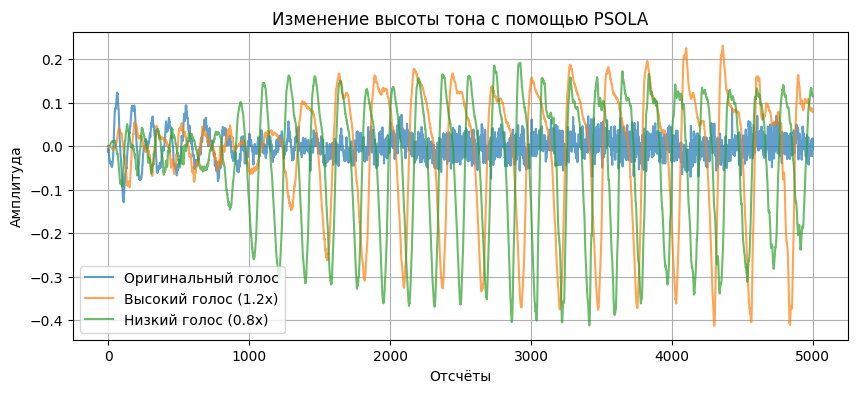

In [ ]:
x_high = my_psola(x, fs, k=1.2)

x_low = my_psola(x, fs, k=0.8)

wavfile.write("high_pitch.wav", fs, (x_high * 32767).astype(np.int16))
wavfile.write("low_pitch.wav", fs, (x_low * 32767).astype(np.int16))

plt.figure(figsize=(10, 4))
plt.plot(x[:5000], label="Оригинальный голос", alpha=0.7)
plt.plot(x_high[:5000], label="Высокий голос (1.2x)", alpha=0.7)
plt.plot(x_low[:5000], label="Низкий голос (0.8x)", alpha=0.7)
plt.legend()
plt.title("Изменение высоты тона с помощью PSOLA")
plt.xlabel("Отсчёты")
plt.ylabel("Амплитуда")
plt.grid()
plt.show()